# Feature importance assessment and validation

This notebook assesses and validates the variables considered most important for downstream $N_2O$ modelling using the preprocessed and aligned, 10-minute resolution dataset. These variables were not originally selected through a formal feature selection procedure. Instead, they were identified earlier in the project as the most operationally and biologically relevant variables, based on literature review, process understanding, and exploratory data analysis. They also informed earlier preprocessing decisions, particularly when determining which periods of the dataset should be excluded due to long contiguous gaps in key signals.

For this reason, the purpose of this notebook is not to perform feature selection from scratch on the raw dataset. Rather, it is to evaluate whether the decisions to treat certain variables as most important are well supported by the processed data and remain justified as the core inputs for subsequent modelling. The analysis therefore provides validation of those earlier decisions, while also assessing whether any additional variables should be retained, deprioritised, or interpreted with caution.

This notebook draws on findings from both the global and localised exploratory data analysis completed prior. In particular, it examines whether variables identified as important in the literature and EDA continue to show meaningful relationships with $N_2O$ in the aligned dataset, and whether those relationships appear consistent enough to support their inclusion in forecasting and classification.

The analysis will consider feature importance from several complementary perspectives. This includes reviewing pairwise relationships with N2O, examining correlations between predictors, checking for redundancy and multicollinearity, and comparing simple statistical and model-based measures of relevance. Where appropriate, these findings will be interpreted in the context of the biological processes governing $N_2O$ production. The notebook also explores whether the selected variables retain useful explanatory and predictive signal for the continuous $N_2O$ response, using simple baseline regression models and feature ablation checks as a preliminary validation step before more advanced modelling.

Overall, this notebook is intended to provide a transparent and defensible justification for the variables carried forward into the modelling stage. The notebook therefore evaluates whether the variables that informed earlier preprocessing decisions remain well justified as core inputs for subsequent modelling.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# Load the dataset
df = pd.read_csv('C:\\Users\\tomor\\Documents\\MSc Lecture Notes\\Data Science Project\\EDS_Design_Project\\data\\EDA\\df_aligned_10T.csv')


print("\nSummary statistics:")
display(data.describe())

display(data.head()) 


Summary statistics:


,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,...,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
count,104187.000000,100612.000000,102432.000000,104186.000000,104189.000000,103775.000000,92585.000000,94568.000000,104187.000000,101368.000000,...,104155.0,94568.000000,104187.000000,101368.000000,92585.0,92585.0,92585.0,104135.000000,90750.000000,92585.0
mean,17132.291864,44.468659,0.128367,2.311440,3.116332,0.653207,0.655996,2187.190458,2.552733,15.660668,...,0.0,0.007487,0.135545,0.099726,0.0,0.0,0.0,0.036942,0.016782,0.0
std,6902.430318,40.268408,0.225162,2.200323,2.772084,0.569319,0.541125,2020.201553,0.852148,3.381365,...,0.0,0.086202,0.342306,0.299635,0.0,0.0,0.0,0.188621,0.128456,0.0
min,0.000000,0.000000,0.000000,0.001582,0.338735,0.004268,0.000000,0.000000,0.000000,8.437862,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
25%,12177.425000,0.000000,0.014931,0.963869,1.525592,0.196253,0.000000,0.000000,2.133368,12.618092,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
50%,16678.066211,43.560001,0.037616,1.870586,2.511954,0.437862,1.000000,2187.724329,2.548539,15.635648,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
75%,21154.550195,85.779999,0.136343,3.025830,4.064101,1.042589,1.040464,3936.867152,2.958140,18.901277,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
max,42997.550781,99.099998,2.093171,20.009645,52.849318,10.886502,2.500000,10164.025195,8.780405,27.126736,...,0.0,1.000000,1.000000,1.000000,0.0,0.0,0.0,1.000000,1.000000,0.0


,Unnamed: 0,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,...,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
0,2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.103247,NaN,1.511840,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
1,2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.141629,NaN,1.496870,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2,2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.324748,NaN,1.514961,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
3,2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.266913,NaN,1.481867,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
4,2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.306728,NaN,1.518550,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0


## Define key variables and assess pairwise relationships

After initial dataset inspection and preprocessing summaries, the next stage of this notebook focuses on the variables previously treated as most important in preprocessing and exploratory analysis. The aim is to examine whether these variables continue to show meaningful relationships with $N_2O$ in the processed dataset, while also checking for redundancy and overlap between predictors. This provides an initial basis for validating the variables taken forward into modelling.

In [7]:
# Define target and key variables for validation

target = "t1_n2o"

key_vars = [
    "t1_nh4",
    "t1_no3",
    "t1_do",
    "t1_airflow",
    "t1_temp",
    "total_airflow",
    "t1_do_sp",
    "t1_ss",
    "t1_po4",
    "inflow",
    "t1_valve_pct"
]

# Keep only columns that actually exist
key_vars = [col for col in key_vars if col in df.columns]

print("Target:", target)
print("Variables being assessed:")
print(key_vars)

Target: t1_n2o
Variables being assessed:
['t1_nh4', 't1_no3', 't1_do', 't1_airflow', 't1_temp', 'total_airflow', 't1_do_sp', 't1_ss', 't1_po4', 'inflow', 't1_valve_pct']


In [8]:
# Spearman correlations with N2O
spearman_corr = (
    df[[target] + key_vars]
    .corr(method="spearman")[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Spearman correlations with t1_n2o:")
display(spearman_corr.to_frame(name="spearman_corr"))

Spearman correlations with t1_n2o:


,spearman_corr
t1_ss,-0.303193
t1_po4,-0.299487
t1_temp,0.139257
t1_nh4,-0.119563
t1_no3,0.114144
t1_do_sp,-0.095790
t1_valve_pct,-0.066925
t1_airflow,-0.051492
total_airflow,0.038757
t1_do,0.023199


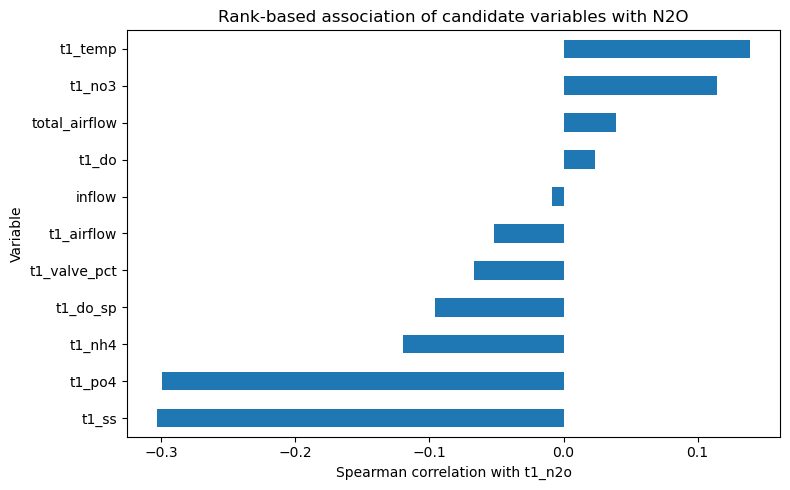

In [9]:
plt.figure(figsize=(8, 5))
spearman_corr.sort_values().plot(kind="barh")
plt.xlabel("Spearman correlation with t1_n2o")
plt.ylabel("Variable")
plt.title("Rank-based association of candidate variables with N2O")
plt.tight_layout()
plt.show()

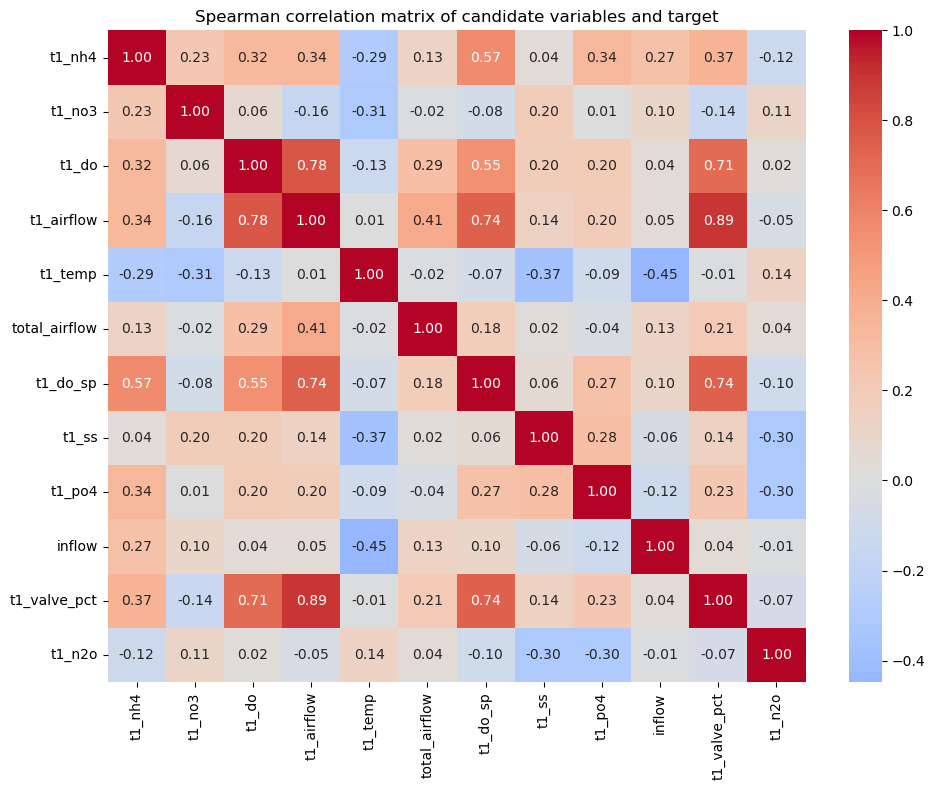

In [13]:
corr_vars = key_vars + [target]
corr_matrix = df[corr_vars].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation matrix of candidate variables and target")
plt.tight_layout()
plt.show()

In [15]:
# Create a working dataframe for the feature assessment stage
feature_df = df[[target] + key_vars].copy()

print("\nShape of feature assessment dataframe:", feature_df.shape)
print("\nMissingness within selected variables (%):")
display((feature_df.isna().mean() * 100).sort_values(ascending=False).to_frame(name="missing_%"))


Shape of feature assessment dataframe: (105264, 12)

Missingness within selected variables (%):


,missing_%
inflow,13.635241
t1_do_sp,12.044954
t1_airflow,10.161119
t1_valve_pct,4.419365
t1_temp,3.701170
t1_n2o,2.690378
t1_do,1.414539
t1_po4,1.072541
t1_nh4,1.024092
total_airflow,1.023142
